# DROID planner — language-conditioned video generation

The DROID WAN 14B planner (`wan-droid-14b`) generates multi-view futures of a real robot
scene from a short context clip and a language prompt. This walkthrough runs two
experiments on the bundled sample clips (three synchronized DROID cameras):

1. **Rolling context** — the same prompt from five different start times in the clip.
2. **Language conditioning** — three different prompts from the same start frame.

**Checkpoints & sample clips** (download once — the full-repo download in the README covers all three rows):

| piece | source | size |
|---|---|---|
| `wan-droid-14b/` (DiT bf16 + `algo_config.yaml`) | `huggingface.co/sizhe-lester-li/VERA` | ~31 GB |
| Wan2.1-I2V-14B-480P base (T5 + VAE + CLIP) | `Wan-AI/Wan2.1-I2V-14B-480P` | ~16 GB |

```bash
export VERA_DROID_CKPT_DIR=./vera-ckpts/wan-droid-14b
export VERA_WAN14B_CKPT_ROOT=/path/to/Wan2.1-I2V-14B-480P
```

Runs on a single GPU with ~60 GB free VRAM (bf16). Each generation takes ~1–2 min.

In [1]:
import os
from pathlib import Path

import av
import numpy as np
import torch
import matplotlib.pyplot as plt
from IPython.display import Video, display
from PIL import Image

from vera.video_model.link.wan_pipeline import WanPipeline, VideoCondition, GenerationConfig
from vera.video_model.utils.video_utils import write_numpy_to_mp4

REPO = Path.cwd().parent if Path.cwd().name == "examples" else Path.cwd()
CKPT_DIR = Path(os.environ.get("VERA_DROID_CKPT_DIR", REPO / "vera-ckpts" / "wan-droid-14b"))
# sample clips: examples/droid_demo_videos if present, else the HF download location
_cand = [REPO / "examples" / "droid_demo_videos", REPO / "vera-ckpts" / "droid-demo-clips"]
VID_DIR = next((d for d in _cand if d.exists()), _cand[0])
OUT_DIR = REPO / "examples" / "outputs" / "droid_generation"
OUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_H, MODEL_W_TOTAL, N_VIEWS = 128, 576, 3   # 3 views side by side on the canvas
VIEW_W = MODEL_W_TOTAL // N_VIEWS
TARGET_FPS = 15
SEED = 11  # fixed for reproducibility; chosen from a small sweep so the bundled outputs show
           # representative prompt-following samples — adherence varies seed to seed

In [2]:
def load_video_frames(path, max_frames=None):
    container = av.open(str(path))
    fps = float(container.streams.video[0].average_rate)
    frames = []
    for i, frame in enumerate(container.decode(video=0)):
        if max_frames is not None and i >= max_frames:
            break
        frames.append(frame.to_ndarray(format="rgb24"))
    container.close()
    return np.stack(frames), fps


def trim_and_resample(frames, src_fps, target_fps):
    ratio = src_fps / target_fps
    idx = [int(round(i * ratio)) for i in range(int(len(frames) / ratio))]
    return frames[[i for i in idx if i < len(frames)]]


def stitch(paths, order):
    aligned = {}
    for name, p in paths.items():
        frames, fps = load_video_frames(p)
        aligned[name] = trim_and_resample(frames, fps, TARGET_FPS)
        print(f"  {name}: {frames.shape} @ {fps:.1f} fps -> {aligned[name].shape[0]} frames @ {TARGET_FPS}")
    n = min(v.shape[0] for v in aligned.values())
    resized = [np.stack([np.array(Image.fromarray(f).resize((VIEW_W, MODEL_H), Image.LANCZOS))
                         for f in aligned[name][:n]]) for name in order]
    return np.concatenate(resized, axis=2)   # [T, H, 3*W, 3] uint8


def to_ctx(frames_uint8):
    t = torch.from_numpy(frames_uint8).float() / 127.5 - 1.0
    return t.permute(0, 3, 1, 2).unsqueeze(0)


def to_uint8(x):
    x = ((x.float() + 1.0) * 127.5).clamp(0, 255).round().to(torch.uint8)
    return x.permute(0, 2, 3, 1).cpu().numpy()


def red_border(frames, px=3):
    frames = frames.copy()
    frames[:, :px], frames[:, -px:] = (220, 30, 30), (220, 30, 30)
    frames[:, :, :px], frames[:, :, -px:] = (220, 30, 30), (220, 30, 30)
    return frames


def show(full, name):
    path = OUT_DIR / name
    write_numpy_to_mp4(full, str(path), fps=TARGET_FPS)
    display(Video(str(path), embed=True, width=1080))

In [3]:
pipeline = WanPipeline.from_config(
    config_path=str(CKPT_DIR / "algo_config.yaml"),
    ckpt_path=str(CKPT_DIR / "video_model.ckpt"),
    device="cuda:0",
    dtype=torch.bfloat16,
)
CTX = pipeline.required_pixel_frames      # context frames the model was trained with
CHUNK = pipeline.future_pixel_frames      # generated frames per call
print(f"context={CTX} frames, generates {CHUNK} frames per call")

context=29 frames, generates 24 frames per call


## Scene 1 — rolling context

One pick-and-place clip, stitched `[external, real, wrist]`. The same prompt is issued
from five different start times, so the generated future begins from progressively later
states of the real episode. Context frames are red-bordered; everything after is generated.

  external: (779, 1080, 1920, 3) @ 30.0 fps -> 389 frames @ 15


  wrist: (2210, 720, 1280, 3) @ 60.0 fps -> 552 frames @ 15


  real: (806, 1080, 1920, 3) @ 30.0 fps -> 403 frames @ 15


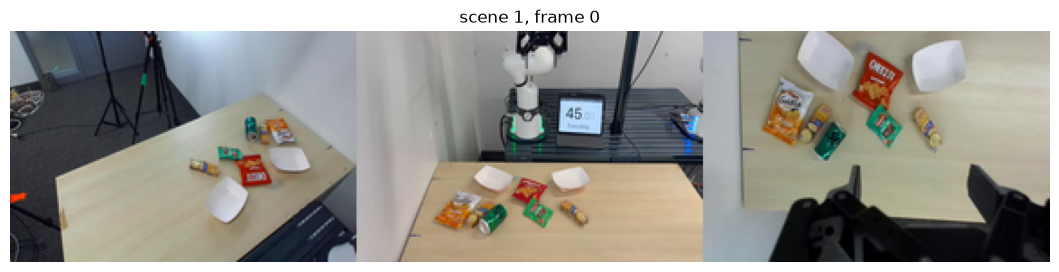

start=0: generated 24 frames


start=10: generated 24 frames


start=20: generated 24 frames


start=30: generated 24 frames


start=40: generated 24 frames


In [4]:
scene1 = stitch({
    "external": VID_DIR / "external_cam.mp4",
    "wrist": VID_DIR / "wrist_cam.mp4",
    "real": VID_DIR / "real.mov",
}, ["external", "real", "wrist"])

plt.figure(figsize=(14, 3)); plt.imshow(scene1[0]); plt.axis("off"); plt.title("scene 1, frame 0"); plt.show()

PROMPT1 = ("a white robot arm reaches down to pick up a line of crackers and then "
           "places it into a white tray.")
for start in [0, 10, 20, 30, 40]:
    torch.manual_seed(SEED + start)
    out = pipeline.generate(
        VideoCondition(context_frames=to_ctx(scene1[start:start + CTX]), text=PROMPT1),
        GenerationConfig(decode_outputs=["rgb"]),
    )
    pred = to_uint8(out["rgb"][0][CTX:])
    print(f"start={start}: generated {pred.shape[0]} frames")
    show(np.concatenate([red_border(scene1[start:start + CTX].copy()), pred], axis=0),
         f"scene1_start{start:03d}.mp4")

## Scene 2 — language conditioning

A tabletop scene with several objects, context fixed at t=0. The prompt is the only thing
that changes between the three generations.

In [5]:
scene2 = stitch({
    "varied_1": VID_DIR / "second_set" / "varied_camera_1_35317039.mp4",
    "varied_2": VID_DIR / "second_set" / "varied_camera_2_39509833.mp4",
    "hand": VID_DIR / "second_set" / "hand_camera_16779706.mp4",
}, ["varied_1", "varied_2", "hand"])

PROMPTS2 = [
    "a white robot arm approaches the tennis ball. Then, its gripper closes on the tennis ball.",
    "a white robot arm approaches the yellow lego brick. Then, its gripper closes on the yellow lego brick.",
    "a white robot arm approaches the yellow teacup. Then, its gripper closes on the yellow teacup on its rim.",
]
for i, prompt in enumerate(PROMPTS2):
    torch.manual_seed(SEED + i)
    out = pipeline.generate(
        VideoCondition(context_frames=to_ctx(scene2[:CTX]), text=prompt),
        GenerationConfig(decode_outputs=["rgb"]),
    )
    pred = to_uint8(out["rgb"][0][CTX:])
    print(f"prompt {i + 1}: {prompt}")
    show(np.concatenate([red_border(scene2[:CTX].copy()), pred], axis=0),
         f"scene2_prompt{i + 1}.mp4")

  varied_1: (152, 720, 1280, 3) @ 30.0 fps -> 76 frames @ 15


  varied_2: (152, 720, 1280, 3) @ 30.0 fps -> 76 frames @ 15


  hand: (152, 720, 1280, 3) @ 30.0 fps -> 76 frames @ 15


prompt 1: a white robot arm approaches the tennis ball. Then, its gripper closes on the tennis ball.


prompt 2: a white robot arm approaches the yellow lego brick. Then, its gripper closes on the yellow lego brick.


prompt 3: a white robot arm approaches the yellow teacup. Then, its gripper closes on the yellow teacup on its rim.


## Notes

- The context length comes from the checkpoint (`pipeline.required_pixel_frames`); guidance
  runs at the trained values from `algo_config.yaml` (`lang_guidance=3.0`, `hist_guidance=2.0`).
- Generation is stochastic; this notebook fixes a seed so reruns reproduce the same futures. Change `SEED` (or drop the `torch.manual_seed` calls) to sample different ones — quality and prompt-adherence vary sample to sample.
- For longer horizons, feed the last `CTX` frames of a generation back in as the next context.